In [ ]:
#  Import Library & Load Dataset

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Menampilkan semua kolom saat print dataframe
pd.set_option('display.max_columns', None)

# Load dataset dari Google Drive
file_path = '/content/drive/MyDrive/machineLearning_PA/depressionDataset.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama
print("=== 5 Data Teratas ===")
display(df.head())

# Informasi struktur dataset
print("\n=== Informasi Dataset ===")
df.info()

Mounted at /content/drive
=== 5 Data Teratas ===


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-

In [ ]:
# Cek jumlah missing values per kolom
print("=== Missing Values per Kolom ===")
print(df.isnull().sum())

# Cek jumlah data duplikat
print("\n=== Jumlah Data Duplikat ===")
print(df.duplicated().sum())

# Cek tipe data dan jumlah unik per kolom
print("\n=== Informasi Data & Jumlah Nilai Unik ===")
print(df.info())
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== Missing Values per Kolom ===
Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

=== Jumlah Data Duplikat ===
0

=== Informasi Data & Jumlah Nilai Unik ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure      

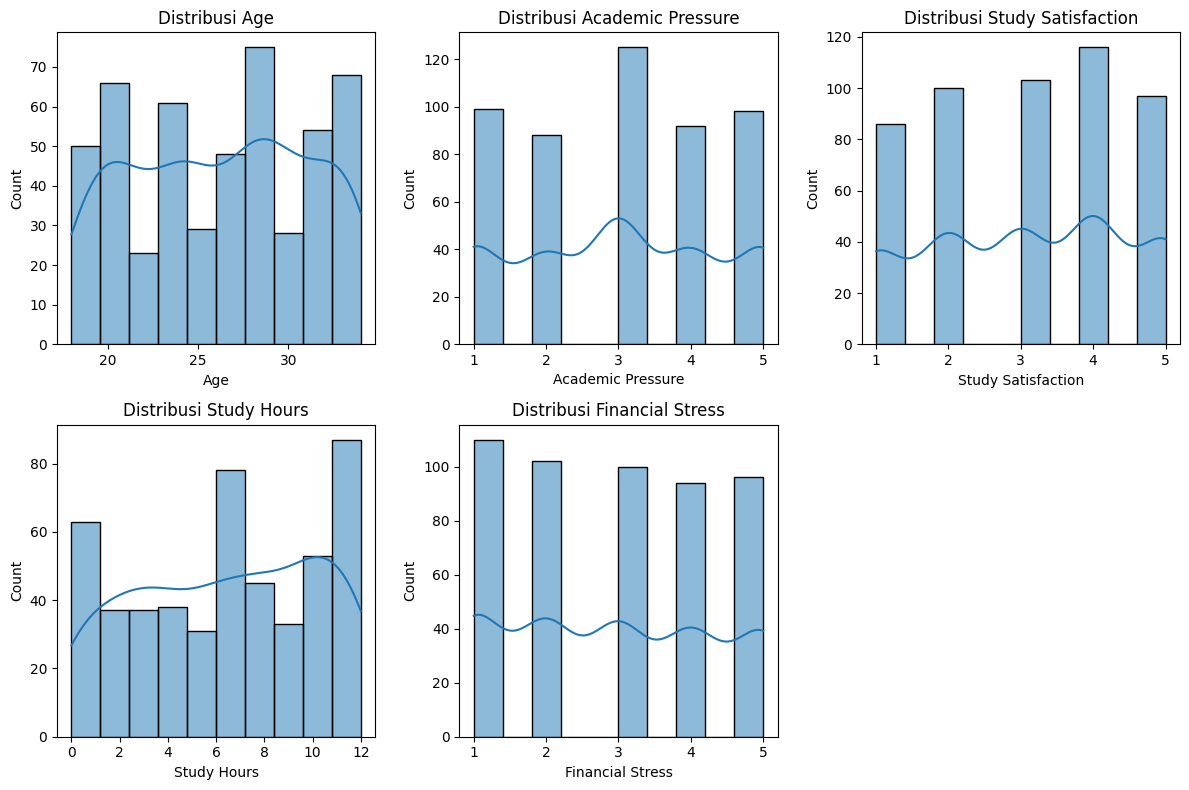

In [ ]:
# Pilih kolom numerik
num_cols = ['Age', 'Academic Pressure', 'Study Satisfaction', 'Study Hours', 'Financial Stress']

# Visualisasi distribusi tiap kolom numerik
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=10)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1505938186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Depression', data=df, palette='pastel')


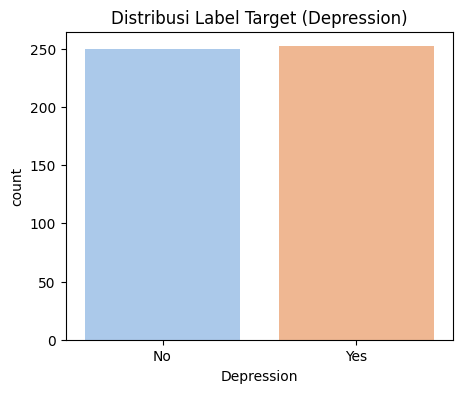

Depression
Yes    50.199203
No     49.800797
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Depression', data=df, palette='pastel')
plt.title('Distribusi Label Target (Depression)')
plt.show()

# Rasio presentase tiap label
print(df['Depression'].value_counts(normalize=True) * 100)

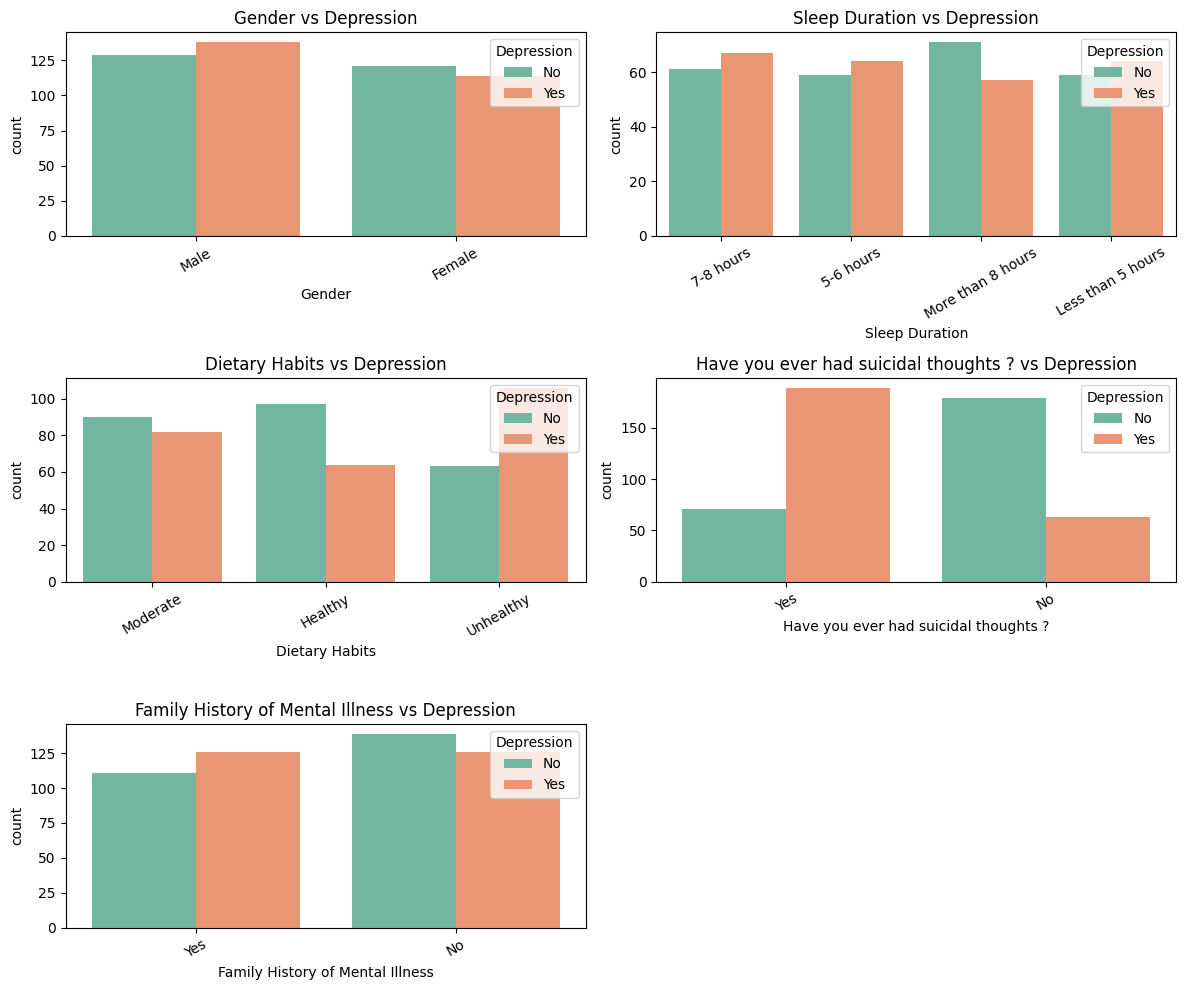

In [ ]:
cat_cols = ['Gender', 'Sleep Duration', 'Dietary Habits',
            'Have you ever had suicidal thoughts ?',
            'Family History of Mental Illness']

plt.figure(figsize=(12, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='Depression', data=df, palette='Set2')
    plt.title(f'{col} vs Depression')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

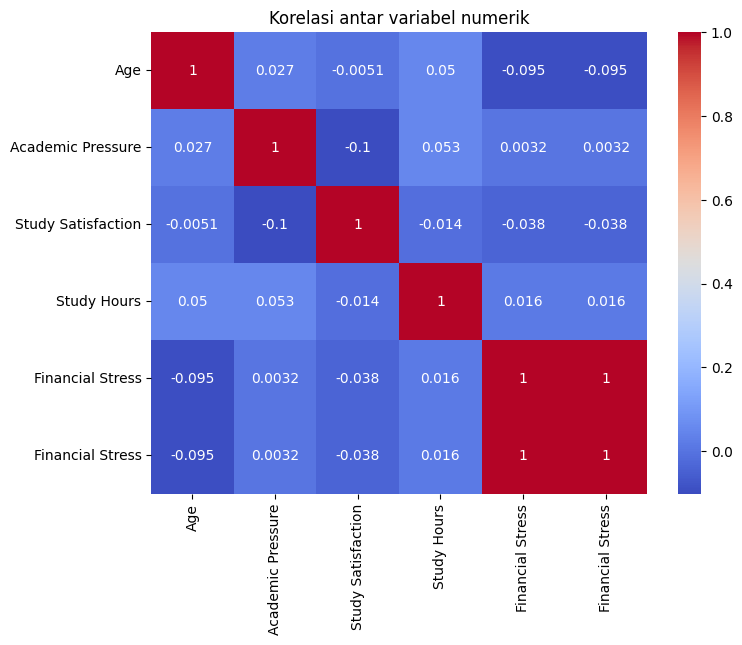

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ['Financial Stress']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi antar variabel numerik')
plt.show()

/tmp/ipython-input-645188696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y=col, data=df, palette='pastel')
/tmp/ipython-input-645188696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y=col, data=df, palette='pastel')
/tmp/ipython-input-645188696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y=col, data=df, palette='pastel')
/tmp/ipython-input-645188696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

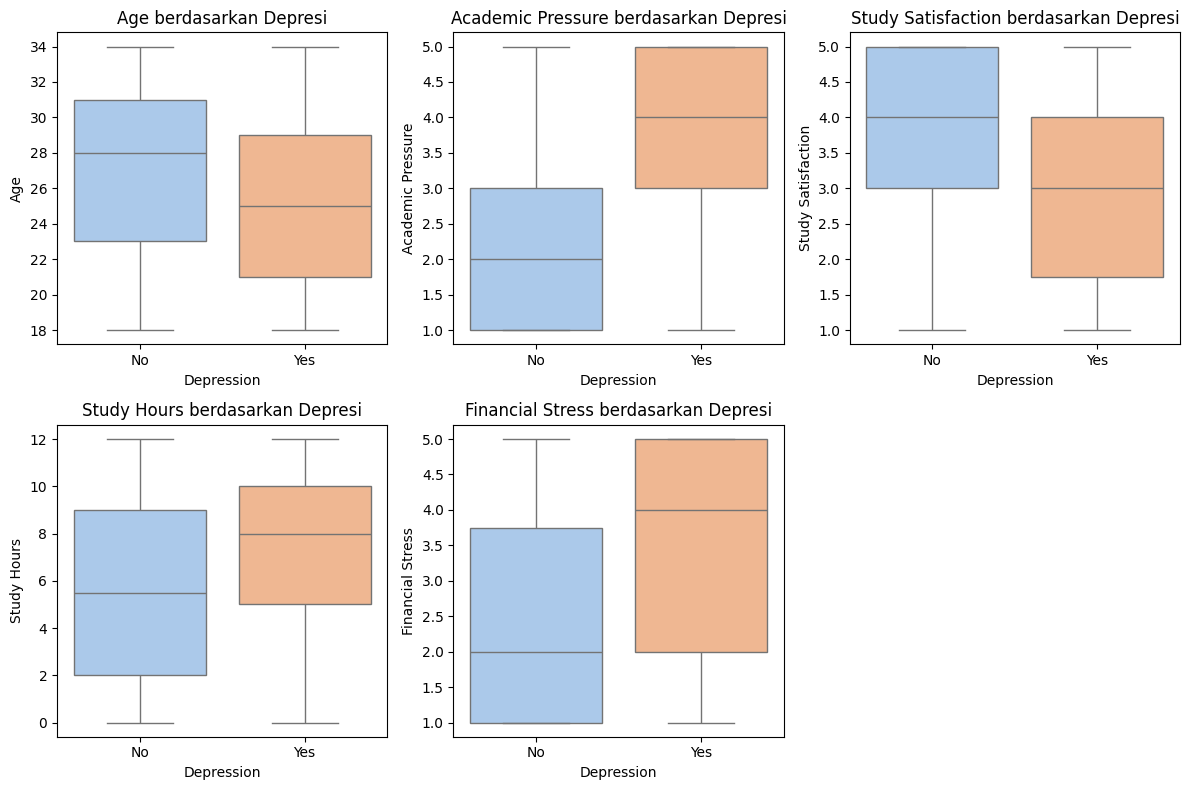

In [ ]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Depression', y=col, data=df, palette='pastel')
    plt.title(f'{col} berdasarkan Depresi')
plt.tight_layout()
plt.show()

In [ ]:
df.head()


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [ ]:
# Ubah label target menjadi numerik
df['Depression'] = df['Depression'].map({'Yes': 1, 'No': 0})

In [ ]:
# Pastikan semua data di Gender jadi string dulu
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower()

# Mapping gender
df['Gender'] = df['Gender'].map({
    'male': 1,
    'female': 0
})

# Jika masih ada kategori lain (misalnya 'other'), jadikan NaN
df['Gender'] = df['Gender'].replace({'nan': np.nan})

# Cek hasilnya
print("=== Unique values in Gender after encoding ===")
print(df['Gender'].value_counts(dropna=False))

=== Unique values in Gender after encoding ===
Gender
1    267
0    235
Name: count, dtype: int64


In [ ]:
# Sleep Duration: ubah ke angka rata-rata jam tidur
# Misal kategori seperti '5-6 hours', '7-8 hours', 'More than 8 hours'
df['Sleep Duration'] = df['Sleep Duration'].replace({
    'Less than 5 hours': 4,
    '5-6 hours': 5.5,
    '7-8 hours': 7.5,
    'More than 8 hours': 9
})

# Dietary Habits: ubah berdasarkan kualitas gizi
df['Dietary Habits'] = df['Dietary Habits'].replace({
    'Unhealthy': 0,
    'Moderate': 1,
    'Healthy': 2
})

# Pernah punya pikiran bunuh diri
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].replace({
    'Yes': 1,
    'No': 0
})

# Riwayat penyakit mental dalam keluarga
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].replace({
    'Yes': 1,
    'No': 0
})

# Cek hasil
df.head()

/tmp/ipython-input-4234597906.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sleep Duration'] = df['Sleep Duration'].replace({
/tmp/ipython-input-4234597906.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Dietary Habits'] = df['Dietary Habits'].replace({
/tmp/ipython-input-4234597906.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,28,2.0,4.0,7.5,1,1,9,2,1,0
1,1,28,4.0,5.0,5.5,2,1,7,1,1,0
2,1,25,1.0,3.0,5.5,0,1,10,4,0,1
3,1,23,1.0,4.0,9.0,0,1,7,2,1,0
4,0,31,1.0,5.0,9.0,2,1,4,2,1,0


In [ ]:
df.isnull().sum()


,0
Gender,0
Age,0
Academic Pressure,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Have you ever had suicidal thoughts ?,0
Study Hours,0
Financial Stress,0
Family History of Mental Illness,0


In [ ]:
# Cek tipe data setiap kolom
print("="*60)
print("TIPE DATA SETIAP KOLOM")
print("="*60)
print(df.dtypes)

TIPE DATA SETIAP KOLOM
Gender                                     int64
Age                                        int64
Academic Pressure                        float64
Study Satisfaction                       float64
Sleep Duration                           float64
Dietary Habits                             int64
Have you ever had suicidal thoughts ?      int64
Study Hours                                int64
Financial Stress                           int64
Family History of Mental Illness           int64
Depression                                 int64
dtype: object


In [ ]:
# Cek apakah semua kolom sudah numerik
non_numeric = df.select_dtypes(exclude=['number']).columns.tolist()
if len(non_numeric) == 0:
    print("✅ Semua kolom sudah bertipe numerik!")
else:
    print(f"⚠️ Kolom yang belum numerik: {non_numeric}")

✅ Semua kolom sudah bertipe numerik!


In [ ]:
# Cek missing values (data kosong)
print("Missing Values per Kolom:")
print(df.isnull().sum())

Missing Values per Kolom:
Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [ ]:
# Total missing values
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")
if total_missing == 0:
    print("✅ Tidak ada data kosong!")
else:
    print("⚠️ Masih ada data kosong, perlu ditangani")

Total missing values: 0
✅ Tidak ada data kosong!


In [ ]:
# Statistik deskriptif dataset
print("Statistik Deskriptif Dataset:")
print(df.describe())

Statistik Deskriptif Dataset:
           Gender         Age  Academic Pressure  Study Satisfaction  \
count  502.000000  502.000000         502.000000          502.000000   
mean     0.531873   26.241036           3.003984            3.075697   
std      0.499481    4.896501           1.390007            1.373490   
min      0.000000   18.000000           1.000000            1.000000   
25%      0.000000   22.000000           2.000000            2.000000   
50%      1.000000   26.500000           3.000000            3.000000   
75%      1.000000   30.000000           4.000000            4.000000   
max      1.000000   34.000000           5.000000            5.000000   

       Sleep Duration  Dietary Habits  Have you ever had suicidal thoughts ?  \
count      502.000000      502.000000                             502.000000   
mean         6.534861        0.984064                               0.517928   
std          1.905523        0.811436                               0.500177   
m

In [ ]:
# Cek dimensi dataset
print(f"Dimensi dataset: {df.shape}")
print(f"Jumlah baris (sampel): {df.shape[0]}")
print(f"Jumlah kolom (fitur + target): {df.shape[1]}")

Dimensi dataset: (502, 11)
Jumlah baris (sampel): 502
Jumlah kolom (fitur + target): 11


In [ ]:
# Persentase distribusi target
print("Persentase Distribusi Depression:")
dist_pct = df['Depression'].value_counts(normalize=True) * 100
print(f"Tidak Depresi (0): {dist_pct[0]:.2f}%")
print(f"Depresi (1): {dist_pct[1]:.2f}%")

Persentase Distribusi Depression:
Tidak Depresi (0): 49.80%
Depresi (1): 50.20%


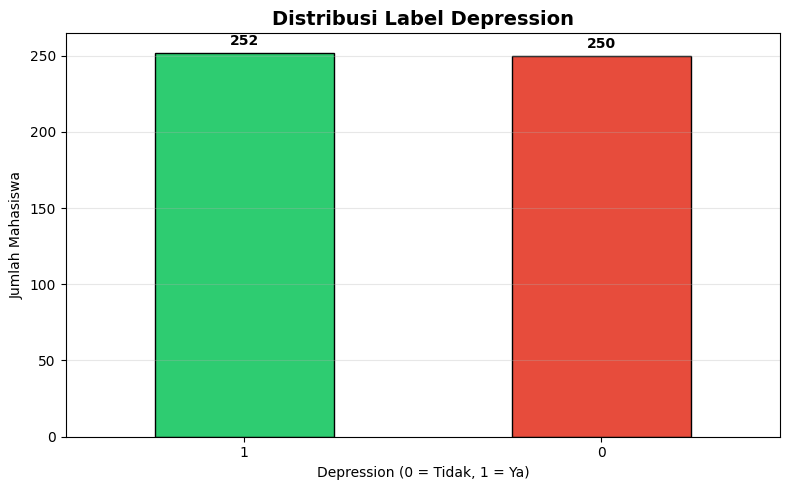

In [ ]:
# Visualisasi distribusi target
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['Depression'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribusi Label Depression', fontsize=14, fontweight='bold')
plt.xlabel('Depression (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=0)

# Tambahkan nilai di atas bar
for i, v in enumerate(df['Depression'].value_counts()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cek range nilai setiap kolom numerik
print("Range Nilai Setiap Kolom:")
for col in df.columns:
    print(f"{col:40s} : Min={df[col].min():6.2f}, Max={df[col].max():6.2f}")

Range Nilai Setiap Kolom:
Gender                                   : Min=  0.00, Max=  1.00
Age                                      : Min= 18.00, Max= 34.00
Academic Pressure                        : Min=  1.00, Max=  5.00
Study Satisfaction                       : Min=  1.00, Max=  5.00
Sleep Duration                           : Min=  4.00, Max=  9.00
Dietary Habits                           : Min=  0.00, Max=  2.00
Have you ever had suicidal thoughts ?    : Min=  0.00, Max=  1.00
Study Hours                              : Min=  0.00, Max= 12.00
Financial Stress                         : Min=  1.00, Max=  5.00
Family History of Mental Illness         : Min=  0.00, Max=  1.00
Depression                               : Min=  0.00, Max=  1.00


In [ ]:
# Cek apakah ada nilai yang tidak wajar (outlier ekstrem)
print("Pengecekan Nilai Tidak Wajar:")
for col in df.select_dtypes(include=['number']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    if len(outliers) > 0:
        print(f"  {col}: {len(outliers)} outlier ekstrem terdeteksi")
    else:
        print(f"  {col}: ✓ Tidak ada outlier ekstrem")

Pengecekan Nilai Tidak Wajar:
  Gender: ✓ Tidak ada outlier ekstrem
  Age: ✓ Tidak ada outlier ekstrem
  Academic Pressure: ✓ Tidak ada outlier ekstrem
  Study Satisfaction: ✓ Tidak ada outlier ekstrem
  Sleep Duration: ✓ Tidak ada outlier ekstrem
  Dietary Habits: ✓ Tidak ada outlier ekstrem
  Have you ever had suicidal thoughts ?: ✓ Tidak ada outlier ekstrem
  Study Hours: ✓ Tidak ada outlier ekstrem
  Financial Stress: ✓ Tidak ada outlier ekstrem
  Family History of Mental Illness: ✓ Tidak ada outlier ekstrem
  Depression: ✓ Tidak ada outlier ekstrem


In [ ]:
# Cek korelasi antar fitur numerik
correlation_matrix = df.corr()
print("Matriks Korelasi:")
print(correlation_matrix)

Matriks Korelasi:
                                         Gender       Age  Academic Pressure  \
Gender                                 1.000000  0.042148          -0.011683   
Age                                    0.042148  1.000000           0.027132   
Academic Pressure                     -0.011683  0.027132           1.000000   
Study Satisfaction                     0.002295 -0.005093          -0.101571   
Sleep Duration                        -0.010083 -0.041869           0.009367   
Dietary Habits                        -0.126789  0.062258           0.014214   
Have you ever had suicidal thoughts ?  0.053635  0.078509           0.037219   
Study Hours                            0.039540  0.050112           0.053024   
Financial Stress                      -0.052867 -0.095348           0.003168   
Family History of Mental Illness      -0.008427 -0.035995          -0.025702   
Depression                             0.031683 -0.215625           0.476259   

                     

In [ ]:
# Summary validasi preprocessing
print("="*60)
print("SUMMARY VALIDASI PREPROCESSING")
print("="*60)
print(f"✓ Total data: {len(df)} sampel")
print(f"✓ Total fitur: {len(df.columns) - 1} (+ 1 target)")
print(f"✓ Tipe data: {'Semua numerik' if len(df.select_dtypes(exclude=['number']).columns) == 0 else 'Masih ada non-numerik'}")
print(f"✓ Missing values: {df.isnull().sum().sum()}")
print(f"✓ Distribusi target: {dist_pct[0]:.1f}% vs {dist_pct[1]:.1f}%")
print("\n✅ Data siap untuk tahap modeling!")
print("="*60)

SUMMARY VALIDASI PREPROCESSING
✓ Total data: 502 sampel
✓ Total fitur: 10 (+ 1 target)
✓ Tipe data: Semua numerik
✓ Missing values: 0
✓ Distribusi target: 49.8% vs 50.2%

✅ Data siap untuk tahap modeling!


**Persiapan Data Modelling**

In [ ]:
# Import library untuk modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

**Pemisahan fitur dan target**

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('Depression', axis=1)
y = df['Depression']

print(f"Dimensi Fitur (X): {X.shape}")
print(f"Dimensi Target (y): {y.shape}")
print(f"\nDaftar Fitur:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Dimensi Fitur (X): (502, 10)
Dimensi Target (y): (502,)

Daftar Fitur:
  1. Gender
  2. Age
  3. Academic Pressure
  4. Study Satisfaction
  5. Sleep Duration
  6. Dietary Habits
  7. Have you ever had suicidal thoughts ?
  8. Study Hours
  9. Financial Stress
  10. Family History of Mental Illness


**Split Data (Training & Testing)**

In [ ]:
# Split data: 80% training, 20% testing dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} data ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} data ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set: 401 data (79.9%)
Testing set: 101 data (20.1%)


In [ ]:
# Cek proporsi kelas di train dan test
print("Proporsi kelas di Training Set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nProporsi kelas di Testing Set:")
print(y_test.value_counts(normalize=True) * 100)

Proporsi kelas di Training Set:
Depression
1    50.124688
0    49.875312
Name: proportion, dtype: float64

Proporsi kelas di Testing Set:
Depression
1    50.49505
0    49.50495
Name: proportion, dtype: float64


**Feature Scalling (Normalisasi)**

In [ ]:
# Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Normalisasi selesai!")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

✓ Normalisasi selesai!
X_train_scaled: (401, 10)
X_test_scaled: (101, 10)


In [ ]:
# Perbandingan statistik sebelum dan sesudah scaling
print("Statistik Training Data:")
print("\nSEBELUM Scaling (3 fitur pertama):")
print(pd.DataFrame(X_train).iloc[:, :3].describe().loc[['mean', 'std']])
print("\nSESUDAH Scaling (3 fitur pertama):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).iloc[:, :3].describe().loc[['mean', 'std']])

Statistik Training Data:

SEBELUM Scaling (3 fitur pertama):
        Gender        Age  Academic Pressure
mean  0.521197  26.281796           3.000000
std   0.500175   4.852102           1.371131

SESUDAH Scaling (3 fitur pertama):
            Gender           Age  Academic Pressure
mean  8.084417e-17  3.123021e-16       2.214909e-18
std   1.001249e+00  1.001249e+00       1.001249e+00


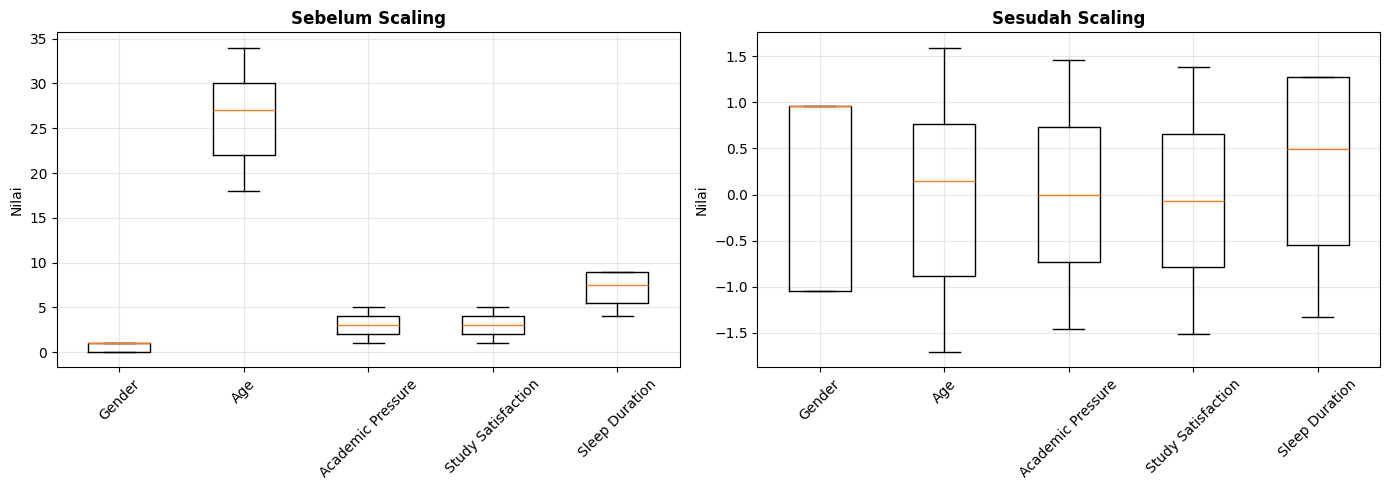

In [ ]:
# Visualisasi perbandingan scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum scaling
axes[0].boxplot([X_train.iloc[:, i] for i in range(min(5, X_train.shape[1]))],
                labels=X.columns[:min(5, X_train.shape[1])])
axes[0].set_title('Sebelum Scaling', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nilai')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Sesudah scaling
axes[1].boxplot([X_train_scaled[:, i] for i in range(min(5, X_train.shape[1]))],
                labels=X.columns[:min(5, X_train.shape[1])])
axes[1].set_title('Sesudah Scaling', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nilai')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Training Model**

In [ ]:
# Inisialisasi dan training model Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model.fit(X_train_scaled, y_train)

print("✓ Model berhasil dilatih!")
print(f"Intercept: {model.intercept_[0]:.4f}")

✓ Model berhasil dilatih!
Intercept: -0.1237


In [ ]:
# Cross-Validation untuk validasi lebih robust
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores (5-Fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score*100:.2f}%)")
print(f"\nRata-rata CV Score: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Standar Deviasi: {cv_scores.std():.4f}")

Cross-Validation Scores (5-Fold):
  Fold 1: 0.9630 (96.30%)
  Fold 2: 1.0000 (100.00%)
  Fold 3: 0.9750 (97.50%)
  Fold 4: 0.9750 (97.50%)
  Fold 5: 1.0000 (100.00%)

Rata-rata CV Score: 0.9826 (98.26%)
Standar Deviasi: 0.0149


In [ ]:
# Koefisien fitur
coefficients = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("Koefisien Fitur (diurutkan berdasarkan pengaruh):")
print(coefficients.to_string(index=False))

Koefisien Fitur (diurutkan berdasarkan pengaruh):
                                Fitur  Koefisien
Have you ever had suicidal thoughts ?   3.297504
                    Academic Pressure   3.082012
                                  Age  -2.037580
                     Financial Stress   1.955166
                   Study Satisfaction  -1.882210
                          Study Hours   1.469347
                       Dietary Habits  -1.140124
                       Sleep Duration  -0.806210
     Family History of Mental Illness   0.682703
                               Gender   0.053652


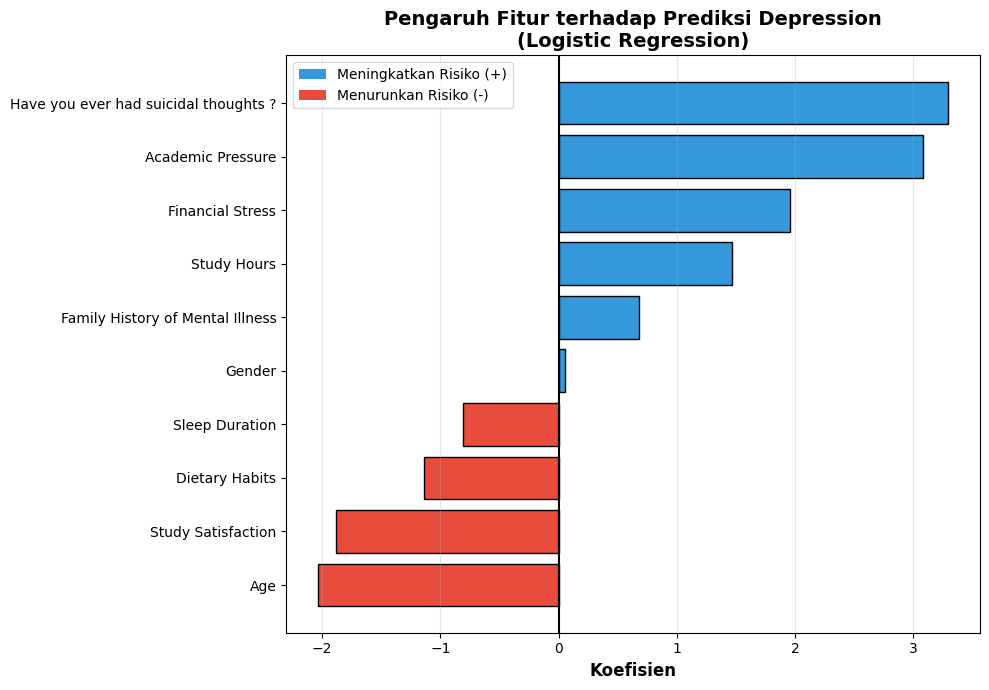

In [ ]:
# Visualisasi koefisien fitur
plt.figure(figsize=(10, 7))
coef_sorted = coefficients.sort_values('Koefisien')
colors = ['#e74c3c' if x < 0 else '#3498db' for x in coef_sorted['Koefisien']]

plt.barh(coef_sorted['Fitur'], coef_sorted['Koefisien'], color=colors, edgecolor='black')
plt.xlabel('Koefisien', fontsize=12, fontweight='bold')
plt.title('Pengaruh Fitur terhadap Prediksi Depression\n(Logistic Regression)',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

# Legend
from matplotlib.patches import Patch
legend = [Patch(facecolor='#3498db', label='Meningkatkan Risiko (+)'),
          Patch(facecolor='#e74c3c', label='Menurunkan Risiko (-)')]
plt.legend(handles=legend, loc='best')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Prediksi**

In [ ]:
# Prediksi data testing
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

print(f"✓ Prediksi selesai untuk {len(y_pred)} data testing")

✓ Prediksi selesai untuk 101 data testing


In [ ]:
# Sample hasil prediksi
hasil_sample = pd.DataFrame({
    'Aktual': y_test.values[:15],
    'Prediksi': y_pred[:15],
    'Prob_0': y_pred_proba[:15, 0].round(3),
    'Prob_1': y_pred_proba[:15, 1].round(3),
    'Status': ['✓' if y_test.values[i] == y_pred[i] else '✗' for i in range(15)]
})

print("Sample Hasil Prediksi (15 data pertama):")
print(hasil_sample.to_string(index=False))

Sample Hasil Prediksi (15 data pertama):
 Aktual  Prediksi  Prob_0  Prob_1 Status
      0         0   1.000   0.000      ✓
      1         1   0.371   0.629      ✓
      1         1   0.010   0.990      ✓
      1         1   0.153   0.847      ✓
      1         1   0.084   0.916      ✓
      0         0   1.000   0.000      ✓
      0         0   0.729   0.271      ✓
      1         1   0.013   0.987      ✓
      0         0   1.000   0.000      ✓
      1         1   0.021   0.979      ✓
      1         1   0.059   0.941      ✓
      0         0   1.000   0.000      ✓
      1         1   0.000   1.000      ✓
      0         0   1.000   0.000      ✓
      0         0   1.000   0.000      ✓


**Evaluasi Model**

In [ ]:
# Hitung semua metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("="*60)
print("METRIK EVALUASI MODEL")
print("="*60)
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score  : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC AUC   : {roc_auc:.4f}")
print("="*60)

METRIK EVALUASI MODEL
Accuracy  : 1.0000 (100.00%)
Precision : 1.0000 (100.00%)
Recall    : 1.0000 (100.00%)
F1-Score  : 1.0000 (100.00%)
ROC AUC   : 1.0000


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negative (TN)  : {tn} (Prediksi: Tidak Depresi, Aktual: Tidak Depresi)")
print(f"False Positive (FP) : {fp} (Prediksi: Depresi, Aktual: Tidak Depresi)")
print(f"False Negative (FN) : {fn} (Prediksi: Tidak Depresi, Aktual: Depresi)")
print(f"True Positive (TP)  : {tp} (Prediksi: Depresi, Aktual: Depresi)")

Confusion Matrix:
[[50  0]
 [ 0 51]]

True Negative (TN)  : 50 (Prediksi: Tidak Depresi, Aktual: Tidak Depresi)
False Positive (FP) : 0 (Prediksi: Depresi, Aktual: Tidak Depresi)
False Negative (FN) : 0 (Prediksi: Tidak Depresi, Aktual: Depresi)
True Positive (TP)  : 51 (Prediksi: Depresi, Aktual: Depresi)


**Visualisasi Hasil**

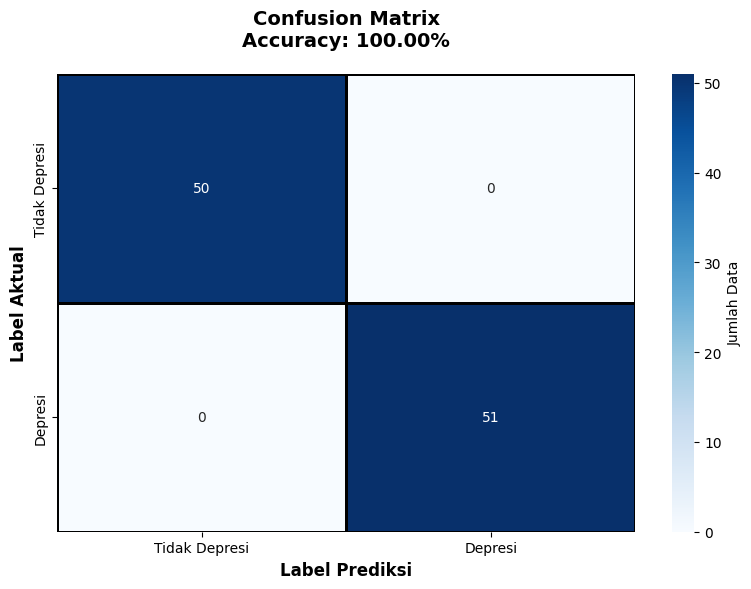

In [ ]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'],
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2, linecolor='black')

plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Label Aktual', fontsize=12, fontweight='bold')
plt.xlabel('Label Prediksi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Classification Report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred,
                          target_names=['Tidak Depresi (0)', 'Depresi (1)'],
                          digits=4))

Classification Report:
                   precision    recall  f1-score   support

Tidak Depresi (0)     1.0000    1.0000    1.0000        50
      Depresi (1)     1.0000    1.0000    1.0000        51

         accuracy                         1.0000       101
        macro avg     1.0000    1.0000    1.0000       101
     weighted avg     1.0000    1.0000    1.0000       101



In [ ]:
# Analisis kesalahan prediksi - False Positives
if fp > 0:
    fp_indices = np.where((y_pred == 1) & (y_test == 0))[0]
    print(f"Analisis False Positive ({fp} kasus):")
    print("Data yang diprediksi Depresi tapi sebenarnya Tidak Depresi")
    print(X_test.iloc[fp_indices[:5]])  # Tampilkan 5 kasus pertama

In [ ]:
# Analisis kesalahan prediksi - False Negatives
if fn > 0:
    fn_indices = np.where((y_pred == 0) & (y_test == 1))[0]
    print(f"Analisis False Negative ({fn} kasus):")
    print("Data yang diprediksi Tidak Depresi tapi sebenarnya Depresi")
    print(X_test.iloc[fn_indices[:5]])  # Tampilkan 5 kasus pertama

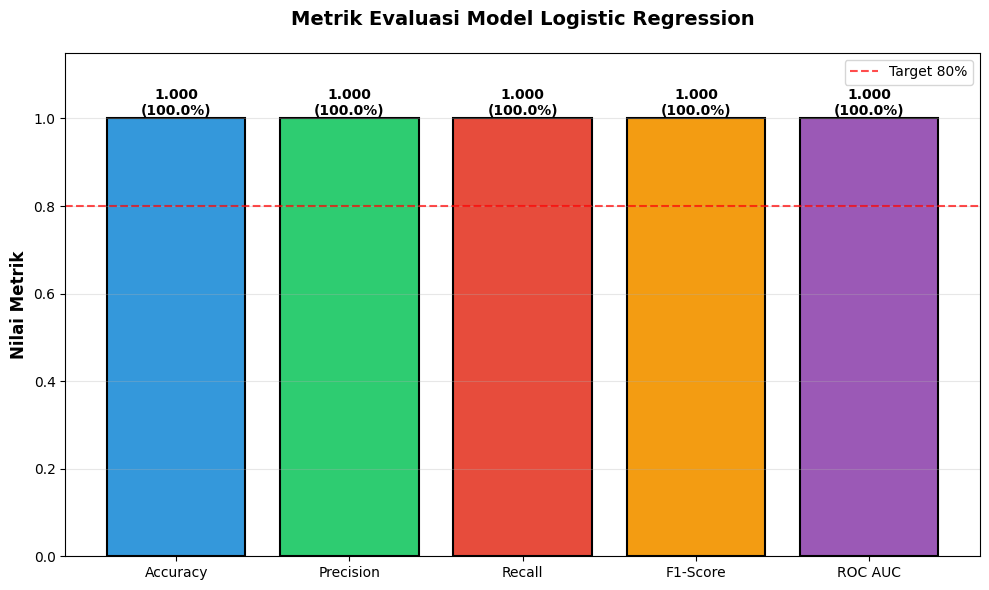

In [ ]:
# Visualisasi Metrik Evaluasi
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC AUC': roc_auc
}

plt.figure(figsize=(10, 6))
colors_metric = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = plt.bar(metrics.keys(), metrics.values(), color=colors_metric,
               edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}\n({height*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, 1.15)
plt.ylabel('Nilai Metrik', fontsize=12, fontweight='bold')
plt.title('Metrik Evaluasi Model Logistic Regression',
          fontsize=14, fontweight='bold', pad=20)
plt.axhline(y=0.8, color='red', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Target 80%')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

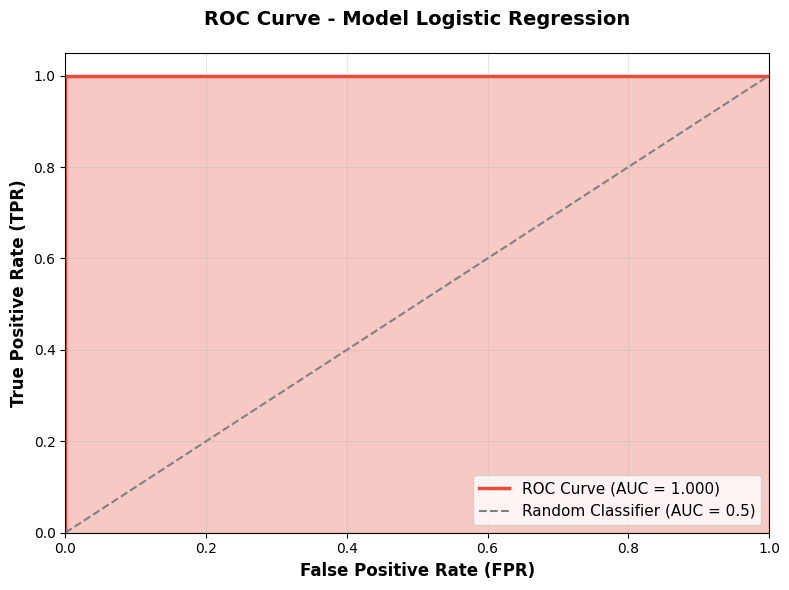

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
         label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Model Logistic Regression',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

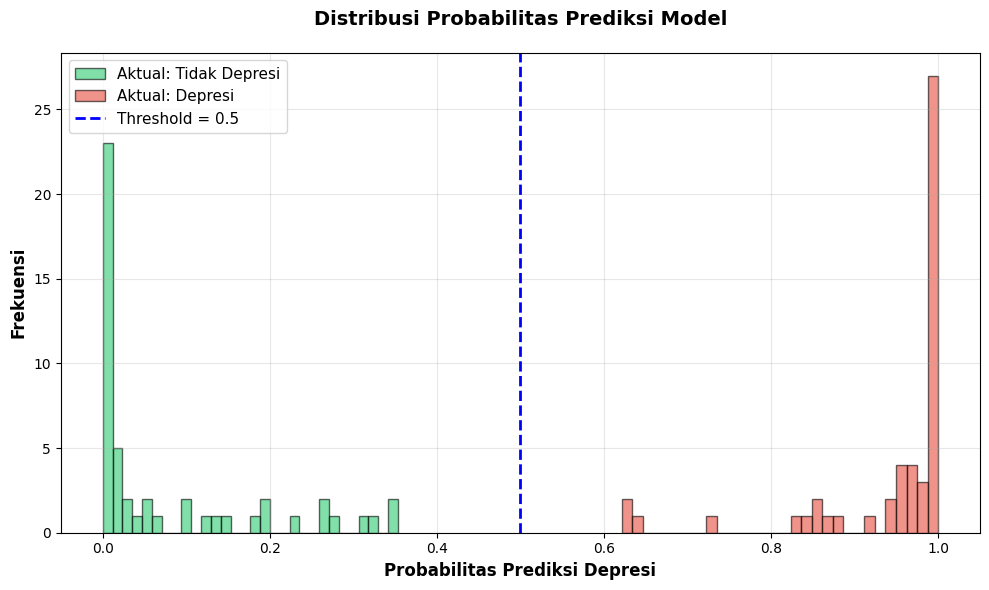

In [ ]:
# Distribusi Probabilitas Prediksi
plt.figure(figsize=(10, 6))

plt.hist(y_pred_proba[y_test == 0, 1], bins=30, alpha=0.6,
         label='Aktual: Tidak Depresi', color='#2ecc71', edgecolor='black')
plt.hist(y_pred_proba[y_test == 1, 1], bins=30, alpha=0.6,
         label='Aktual: Depresi', color='#e74c3c', edgecolor='black')
plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=2,
            label='Threshold = 0.5')

plt.xlabel('Probabilitas Prediksi Depresi', fontsize=12, fontweight='bold')
plt.ylabel('Frekuensi', fontsize=12, fontweight='bold')
plt.title('Distribusi Probabilitas Prediksi Model',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Perbandingan dengan Baseline**

In [ ]:
# Perbandingan dengan Baseline (Majority Class Classifier)
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Perbandingan dengan Baseline:")
print(f"Baseline Accuracy (Majority Class): {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Improvement: {(accuracy - baseline_accuracy)*100:.2f}%")

Perbandingan dengan Baseline:
Baseline Accuracy (Majority Class): 0.5050 (50.50%)
Model Accuracy: 1.0000 (100.00%)
Improvement: 49.50%


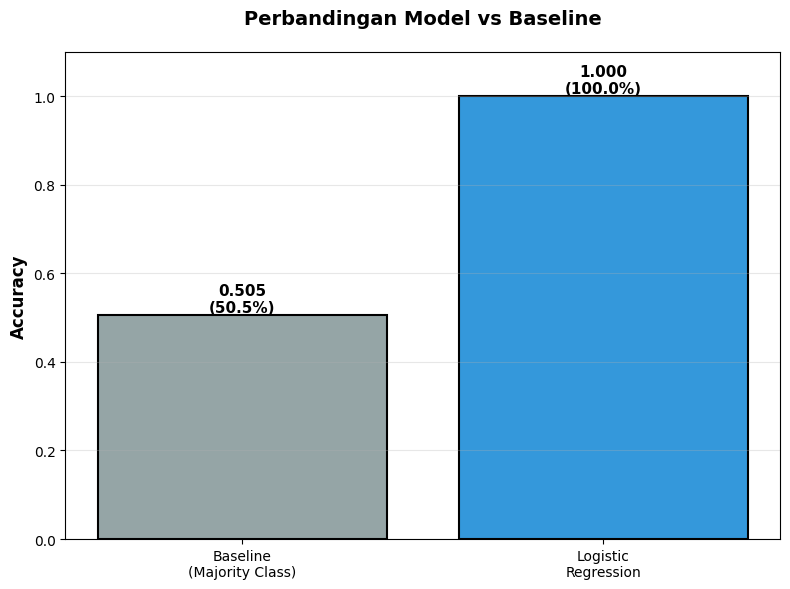

In [ ]:
# Visualisasi perbandingan dengan baseline
comparison = pd.DataFrame({
    'Model': ['Baseline\n(Majority Class)', 'Logistic\nRegression'],
    'Accuracy': [baseline_accuracy, accuracy]
})

plt.figure(figsize=(8, 6))
bars = plt.bar(comparison['Model'], comparison['Accuracy'],
               color=['#95a5a6', '#3498db'], edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}\n({height*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Perbandingan Model vs Baseline', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Ringkasan Hasil**

In [ ]:
# Ringkasan Hasil Penelitian
print("="*70)
print("RINGKASAN HASIL PENELITIAN")
print("="*70)
print(f"\n📊 DATASET:")
print(f"  • Total data           : {len(df)} mahasiswa")
print(f"  • Jumlah fitur         : {X.shape[1]} variabel")
print(f"  • Training set         : {len(X_train)} data ({len(X_train)/len(X)*100:.1f}%)")
print(f"  • Testing set          : {len(X_test)} data ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n🤖 MODEL:")
print(f"  • Algoritma            : Logistic Regression")
print(f"  • Jenis                : Supervised Learning - Binary Classification")
print(f"  • Preprocessing        : Label Encoding + StandardScaler")
print(f"  • Cross-Validation     : {cv_scores.mean():.4f} (5-Fold CV)")

print(f"\n📈 PERFORMA MODEL:")
print(f"  • Accuracy             : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  • Precision            : {precision:.4f} ({precision*100:.2f}%)")
print(f"  • Recall               : {recall:.4f} ({recall*100:.2f}%)")
print(f"  • F1-Score             : {f1:.4f} ({f1*100:.2f}%)")
print(f"  • ROC AUC Score        : {roc_auc:.4f}")
print(f"  • Baseline Accuracy    : {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  • Improvement          : +{(accuracy-baseline_accuracy)*100:.2f}%")

print(f"\n📉 CONFUSION MATRIX:")
print(f"  • True Negative (TN)   : {tn} data")
print(f"  • False Positive (FP)  : {fp} data")
print(f"  • False Negative (FN)  : {fn} data")
print(f"  • True Positive (TP)   : {tp} data")

print(f"\n🎯 FITUR PALING BERPENGARUH (Top 3):")
for i in range(min(3, len(coefficients))):
    fitur = coefficients.iloc[i]['Fitur']
    koef = coefficients.iloc[i]['Koefisien']
    pengaruh = "↑ Meningkatkan" if koef > 0 else "↓ Menurunkan"
    print(f"  {i+1}. {fitur:35s} : {koef:8.4f} ({pengaruh})")

print("\n" + "="*70)
print("✓ ANALISIS SELESAI")
print("="*70)

RINGKASAN HASIL PENELITIAN

📊 DATASET:
  • Total data           : 502 mahasiswa
  • Jumlah fitur         : 10 variabel
  • Training set         : 401 data (79.9%)
  • Testing set          : 101 data (20.1%)

🤖 MODEL:
  • Algoritma            : Logistic Regression
  • Jenis                : Supervised Learning - Binary Classification
  • Preprocessing        : Label Encoding + StandardScaler
  • Cross-Validation     : 0.9826 (5-Fold CV)

📈 PERFORMA MODEL:
  • Accuracy             : 1.0000 (100.00%)
  • Precision            : 1.0000 (100.00%)
  • Recall               : 1.0000 (100.00%)
  • F1-Score             : 1.0000 (100.00%)
  • ROC AUC Score        : 1.0000
  • Baseline Accuracy    : 0.5050 (50.50%)
  • Improvement          : +49.50%

📉 CONFUSION MATRIX:
  • True Negative (TN)   : 50 data
  • False Positive (FP)  : 0 data
  • False Negative (FN)  : 0 data
  • True Positive (TP)   : 51 data

🎯 FITUR PALING BERPENGARUH (Top 3):
  1. Have you ever had suicidal thoughts ? :   3.2975 (↑ 

**Simpan Model**

In [ ]:
# Simpan model dan scaler
import pickle

# Simpan model
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Simpan scaler
with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Simpan hasil evaluasi
hasil_evaluasi = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'confusion_matrix': cm.tolist(),
    'cv_scores': cv_scores.tolist(),
    'feature_coefficients': coefficients.to_dict()
}

with open('hasil_evaluasi.pkl', 'wb') as f:
    pickle.dump(hasil_evaluasi, f)

print("✓ Model berhasil disimpan: logistic_regression_model.pkl")
print("✓ Scaler berhasil disimpan: standard_scaler.pkl")
print("✓ Hasil evaluasi berhasil disimpan: hasil_evaluasi.pkl")

✓ Model berhasil disimpan: logistic_regression_model.pkl
✓ Scaler berhasil disimpan: standard_scaler.pkl
✓ Hasil evaluasi berhasil disimpan: hasil_evaluasi.pkl


In [ ]:
# Import library untuk Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("TRAINING MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*60)

TRAINING MODEL 2: RANDOM FOREST CLASSIFIER


In [ ]:
# Inisialisasi Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Jumlah decision trees
    max_depth=10,          # Kedalaman maksimal tree
    random_state=42,
    n_jobs=-1              # Gunakan semua CPU core
)

# Training model
print("\n🌲 Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("✓ Random Forest berhasil dilatih!")


🌲 Training Random Forest...
✓ Random Forest berhasil dilatih!


In [ ]:
# Prediksi dengan Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

print("✓ Prediksi selesai!")

✓ Prediksi selesai!


In [ ]:
# Evaluasi Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf[:, 1])

print("="*60)
print("HASIL EVALUASI RANDOM FOREST")
print("="*60)
print(f"Accuracy  : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision : {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"Recall    : {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"F1-Score  : {rf_f1:.4f} ({rf_f1*100:.2f}%)")
print(f"ROC AUC   : {rf_roc_auc:.4f}")
print("="*60)

HASIL EVALUASI RANDOM FOREST
Accuracy  : 0.9208 (92.08%)
Precision : 0.8909 (89.09%)
Recall    : 0.9608 (96.08%)
F1-Score  : 0.9245 (92.45%)
ROC AUC   : 0.9812


In [ ]:
# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("Confusion Matrix - Random Forest:")
print(cm_rf)
print(f"\nTrue Negative  : {tn_rf}")
print(f"False Positive : {fp_rf}")
print(f"False Negative : {fn_rf}")
print(f"True Positive  : {tp_rf}")

Confusion Matrix - Random Forest:
[[44  6]
 [ 2 49]]

True Negative  : 44
False Positive : 6
False Negative : 2
True Positive  : 49


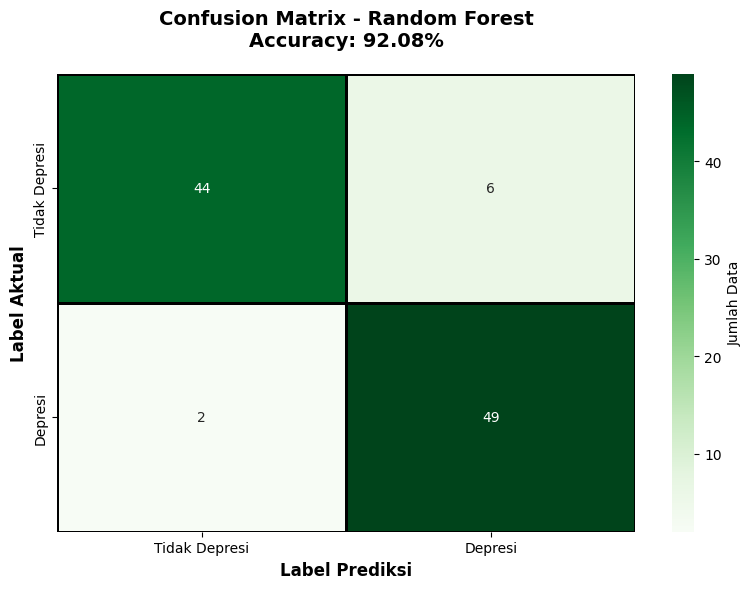

In [ ]:
# Visualisasi Confusion Matrix Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'],
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2, linecolor='black')

plt.title(f'Confusion Matrix - Random Forest\nAccuracy: {rf_accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Label Aktual', fontsize=12, fontweight='bold')
plt.xlabel('Label Prediksi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Import library untuk SVM
from sklearn.svm import SVC

print("="*60)
print("TRAINING MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

TRAINING MODEL 3: SUPPORT VECTOR MACHINE (SVM)


In [ ]:
# Inisialisasi SVM
svm_model = SVC(
    kernel='rbf',          # Radial Basis Function kernel
    C=1.0,                 # Regularization parameter
    gamma='scale',         # Kernel coefficient
    probability=True,      # Enable probability estimates
    random_state=42
)

# Training model
print("\n⚙️ Training SVM...")
svm_model.fit(X_train_scaled, y_train)
print("✓ SVM berhasil dilatih!")


⚙️ Training SVM...
✓ SVM berhasil dilatih!


In [ ]:
# Prediksi dengan SVM
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

print("✓ Prediksi selesai!")

✓ Prediksi selesai!


In [ ]:
# Evaluasi SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_pred_proba_svm[:, 1])

print("="*60)
print("HASIL EVALUASI SVM")
print("="*60)
print(f"Accuracy  : {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"Precision : {svm_precision:.4f} ({svm_precision*100:.2f}%)")
print(f"Recall    : {svm_recall:.4f} ({svm_recall*100:.2f}%)")
print(f"F1-Score  : {svm_f1:.4f} ({svm_f1*100:.2f}%)")
print(f"ROC AUC   : {svm_roc_auc:.4f}")
print("="*60)

HASIL EVALUASI SVM
Accuracy  : 0.9505 (95.05%)
Precision : 0.9107 (91.07%)
Recall    : 1.0000 (100.00%)
F1-Score  : 0.9533 (95.33%)
ROC AUC   : 0.9984


In [ ]:
# Confusion Matrix SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
tn_svm, fp_svm, fn_svm, tp_svm = cm_svm.ravel()

print("Confusion Matrix - SVM:")
print(cm_svm)
print(f"\nTrue Negative  : {tn_svm}")
print(f"False Positive : {fp_svm}")
print(f"False Negative : {fn_svm}")
print(f"True Positive  : {tp_svm}")

Confusion Matrix - SVM:
[[45  5]
 [ 0 51]]

True Negative  : 45
False Positive : 5
False Negative : 0
True Positive  : 51


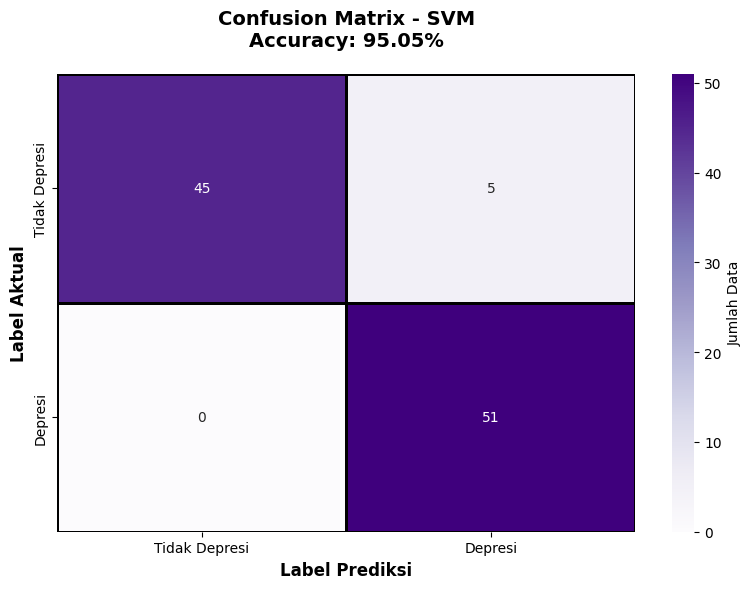

In [ ]:
# Visualisasi Confusion Matrix SVM
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'],
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2, linecolor='black')

plt.title(f'Confusion Matrix - SVM\nAccuracy: {svm_accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Label Aktual', fontsize=12, fontweight='bold')
plt.xlabel('Label Prediksi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Buat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy, rf_accuracy, svm_accuracy],
    'Precision': [precision, rf_precision, svm_precision],
    'Recall': [recall, rf_recall, svm_recall],
    'F1-Score': [f1, rf_f1, svm_f1],
    'ROC AUC': [roc_auc, rf_roc_auc, svm_roc_auc]
})

print("="*70)
print("PERBANDINGAN PERFORMA 3 MODEL")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

PERBANDINGAN PERFORMA 3 MODEL
              Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
Logistic Regression  1.000000   1.000000 1.000000  1.000000 1.000000
      Random Forest  0.920792   0.890909 0.960784  0.924528 0.981176
                SVM  0.950495   0.910714 1.000000  0.953271 0.998431


In [ ]:
# Tampilkan dalam format persentase
comparison_pct = comparison_df.copy()
comparison_pct['Accuracy'] = comparison_pct['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
comparison_pct['Precision'] = comparison_pct['Precision'].apply(lambda x: f"{x*100:.2f}%")
comparison_pct['Recall'] = comparison_pct['Recall'].apply(lambda x: f"{x*100:.2f}%")
comparison_pct['F1-Score'] = comparison_pct['F1-Score'].apply(lambda x: f"{x*100:.2f}%")
comparison_pct['ROC AUC'] = comparison_pct['ROC AUC'].apply(lambda x: f"{x:.4f}")

print("\nPERBANDINGAN DALAM PERSENTASE:")
print(comparison_pct.to_string(index=False))


PERBANDINGAN DALAM PERSENTASE:
              Model Accuracy Precision  Recall F1-Score ROC AUC
Logistic Regression  100.00%   100.00% 100.00%  100.00%  1.0000
      Random Forest   92.08%    89.09%  96.08%   92.45%  0.9812
                SVM   95.05%    91.07% 100.00%   95.33%  0.9984


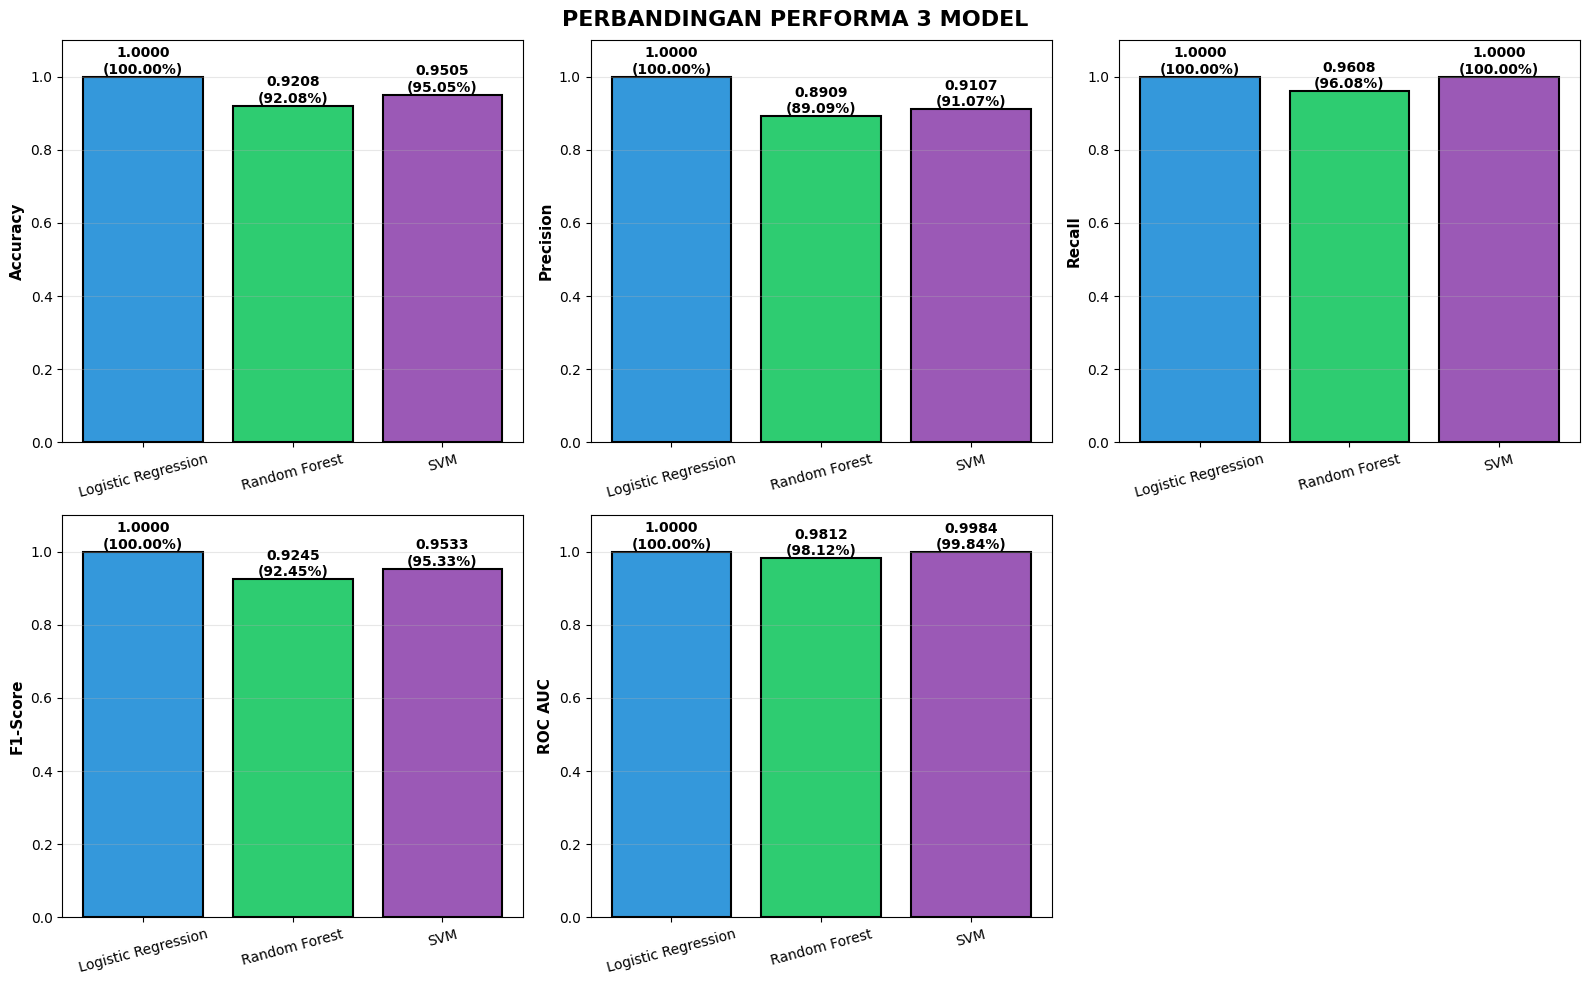

In [ ]:
# Bar Chart Perbandingan Accuracy
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PERBANDINGAN PERFORMA 3 MODEL', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
colors = ['#3498db', '#2ecc71', '#9b59b6']

# Plot setiap metrik
for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3

    values = comparison_df[metric].values
    bars = axes[row, col].bar(comparison_df['Model'], values, color=colors,
                               edgecolor='black', linewidth=1.5)

    # Tambahkan nilai di atas bar
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{values[i]:.4f}\n({values[i]*100:.2f}%)',
                           ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[row, col].set_ylabel(metric, fontsize=11, fontweight='bold')
    axes[row, col].set_ylim(0, 1.1)
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].tick_params(axis='x', rotation=15)

# Hapus subplot kosong
fig.delaxes(axes[1, 2])

plt.tight_layout()

# -----------------------------------------
# ⭐ Simpan sebagai PNG resolusi tinggi
plt.savefig("perbandingan_model_highres.png", dpi=300, bbox_inches='tight')
# -----------------------------------------

plt.show()